In [1]:
from imports import *
%reload_ext autoreload
%autoreload 2

In [3]:
df = pd.read_excel('./dataset/oecd_dataset.xlsx', index_col='Reference area')
df = df[df.notnull().all(axis=1)]

In [4]:
df.round(1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,,
Australia,11860732.7,12063021.4,12455751.1,13723725.9,14701734.3,15461977.2,14738096.5,6112265.9,3984941.1,7525983.5,11298137.3,12870576.0
Austria,2032032.3,2138526.6,2219886.6,2289076.6,2294330.9,2556748.9,2966439.4,1041594.6,1240233.6,2078696.9,2469198.6,2682274.5
Belgium,3247814.2,3195722.8,3413040.5,3466534.3,3672222.0,3940235.8,4039798.5,2236333.8,3240717.6,3894086.3,3766052.1,3930514.0
Canada,9517376.7,10106189.4,10706255.2,11606782.6,12420954.4,13083421.6,13824361.0,5671979.1,5128085.8,9490621.0,11469309.5,12787228.3
Chile,1645285.3,1679696.5,1833572.8,1939507.5,2081471.4,2191711.5,2235390.1,1207357.4,1204832.9,1717065.8,1965011.6,2204970.0
...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,29525.4,26833.0,24494.2,22117.6,24196.7,28061.3,25512.0,5878.3,3157.2,11358.0,22313.9,11515.7
Venezuela,991198.7,715855.8,603853.4,573210.9,434663.1,400566.1,313361.9,74626.3,104650.5,193219.5,278163.1,245325.9
Viet Nam,2142564.9,2305220.9,2567449.5,3019055.6,3616451.4,4230438.4,4941541.3,1822487.4,1497054.1,2383585.2,4106124.5,3527683.0


<Axes: >

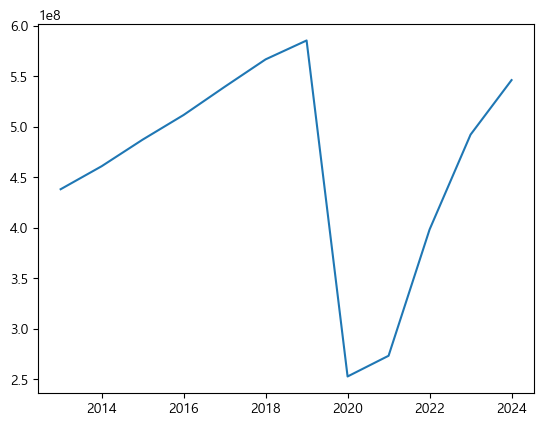

In [5]:
sns.lineplot(data=df.sum())

* 결측을 제외한 183개를 대상으로 분석함

In [6]:
years = np.arange(2013, 2020).tolist()
df_num = df.copy()
df_num = np.log(df_num) #[years])  # 로그 변환

# 연도별 로그 성장률
growth = df_num.diff(axis=1).iloc[:, 1:]  # 2014~2024
display(growth)
print('''
연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.
''')

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,
Australia,0.016912,0.032038,0.096944,0.068839,0.050418,-0.047948,-0.880138,-0.427775,0.635839,0.406276,0.130306
Austria,0.051081,0.037339,0.030692,0.002293,0.108295,0.148626,-1.046610,0.174547,0.516441,0.172152,0.082771
Belgium,-0.016169,0.065790,0.015552,0.057642,0.070444,0.024954,-0.591357,0.370957,0.183664,-0.033432,0.042743
Canada,0.060029,0.057680,0.080761,0.067795,0.051961,0.055086,-0.890894,-0.100806,0.615572,0.189371,0.108772
Chile,0.020699,0.087653,0.056168,0.070641,0.051608,0.019733,-0.615982,-0.002093,0.354276,0.134881,0.115216
...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,-0.095619,-0.091196,-0.102060,0.089843,0.148172,-0.095241,-1.467890,-0.621560,1.280222,0.675291,-0.661496
Venezuela,-0.325436,-0.170147,-0.052078,-0.276682,-0.081692,-0.245520,-1.434865,0.338132,0.613201,0.364381,-0.125620
Viet Nam,0.073173,0.107736,0.162031,0.180549,0.156812,0.155372,-0.997475,-0.196703,0.465106,0.543874,-0.151838



연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.



In [7]:
pd.DataFrame(data = {'mean': growth.mean(), 'std': growth.std(ddof=1)}).round(5)

,mean,std
2014,0.02657,0.20309
2015,0.04216,0.15699
2016,0.06623,0.17502
2017,0.07171,0.12196
2018,0.05773,0.09936
2019,-0.06510,0.57239
2020,-0.90339,0.31789
2021,0.15670,0.46140
2022,0.40957,0.45794
2023,0.24612,0.48496


전체 연도별 로그 성장률의 평균: 0.03322
전체 연도별 로그 성장률의 분산: 0.07664
전체 연도별 로그 성장률의 표준편차: 0.27684


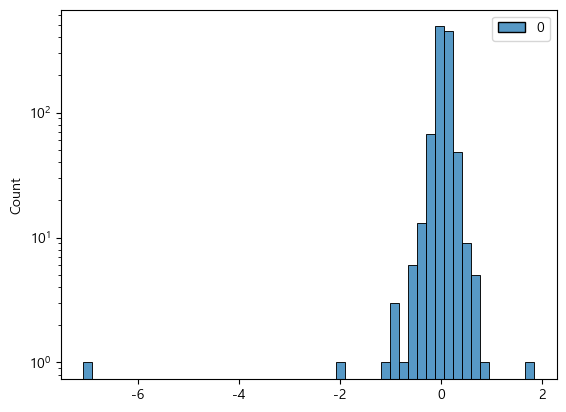

In [49]:
# 전체 풀링 (NaN 제거)
all_growth = growth.values.flatten()

overall_mean = all_growth.mean()
overall_var  = all_growth.var(ddof=1)  # 표본분산
overall_std  = all_growth.std(ddof=1)

print(f'''전체 연도별 로그 성장률의 평균: {overall_mean:.5f}
전체 연도별 로그 성장률의 분산: {overall_var:.5f}
전체 연도별 로그 성장률의 표준편차: {overall_std:.5f}''')
sns.histplot([all_growth], bins=50, multiple='dodge')
plt.yscale('log')

[(2, 928.2928742228207, 956.3297813510197), (3, 804.5726615615397, 849.431712966658), (4, 707.6379154469994, 769.3191111290371), (5, 804.9403172149597, 883.4436571739168), (6, 696.5454230212373, 791.8709072571137), (7, 673.2116125429761, 785.3592410557719), (8, 681.6400432884504, 810.6098160781656), (9, 659.8519874391739, 805.6439045058085), (10, 638.9638311978438, 801.5778925413977), (11, 667.1442769467517, 846.580482567225), (12, 631.9607951940282, 828.2191450914208), (13, 641.2699384966678, 854.3504326709799), (14, 632.4398442983907, 862.3424827496221), (15, 640.0174715640526, 886.7422542922034), (16, 642.8885950650655, 906.4355220701357), (17, 647.7000890450995, 928.0691603270891), (18, 651.1133519919497, 948.3045675508586), (19, 657.1745474978244, 971.1879073336527)]


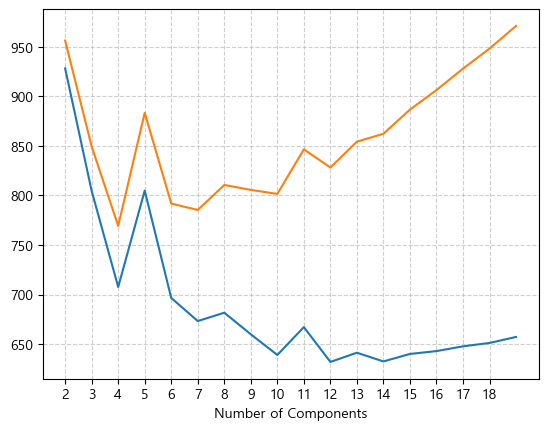

In [31]:
from sklearn.mixture import GaussianMixture

X = all_growth.reshape(-1,1)

res = []
for k in range(2,20):
    gmm = GaussianMixture(n_components=k, random_state=0)
    gmm.fit(X)
    res.append((k, gmm.aic(X), gmm.bic(X)))


res_df = pd.DataFrame(res, columns=['n_components', 'AIC', 'BIC'])
import matplotlib.pyplot as plt
Ks = np.arange(1, len(res_df) + 1)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.xticks(np.arange(1, max(Ks) + 1, 1))
plt.plot(res_df['n_components'], res_df['AIC'], label='AIC')
plt.plot(res_df['n_components'], res_df['BIC'], label='BIC')
plt.xlabel('Number of Components')
print(res)



(이상치 제거)
전체 연도별 로그 성장률의 평균: 0.07943
전체 연도별 로그 성장률의 분산: 0.02104
전체 연도별 로그 성장률의 표준편차: 0.14506


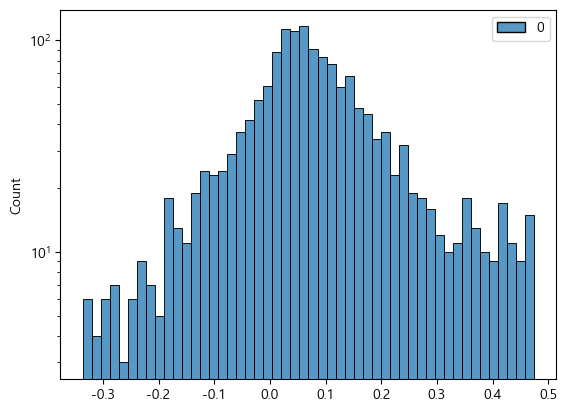

In [13]:
# 극단치를 제거한 성장률 평균, 분산, 표준편차 구하기
## IQR 방법
q1 = np.nanpercentile(all_growth, 25)
q3 = np.nanpercentile(all_growth, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
trimmed_growth = all_growth[(all_growth >= lower_bound) & (all_growth <= upper_bound)]

print(f'''
(이상치 제거)
전체 연도별 로그 성장률의 평균: {np.nanmean(trimmed_growth):.5f}
전체 연도별 로그 성장률의 분산: {np.nanvar(trimmed_growth):.5f}
전체 연도별 로그 성장률의 표준편차: {np.nanstd(trimmed_growth):.5f}''')
sns.histplot([trimmed_growth], bins=50, multiple='dodge')
plt.yscale('log')

[(2, -1690.7687516004294, -1663.8178444592972), (3, -1818.6421572754457, -1775.5207058496342), (4, -1835.5824076290257, -1776.290411918535), (5, -1829.4586777830214, -1753.9961377878512), (6, -1841.222387277461, -1749.5893029976116), (7, -1836.239400282106, -1728.4357717175776), (8, -1835.837662829464, -1711.8634899802562), (9, -1837.3252760993505, -1697.1805589654634), (10, -1833.5350679899313, -1677.2198065713649), (11, -1830.701377328722, -1658.2155716254763), (12, -1828.6214464321047, -1639.9650964441796), (13, -1829.250489516381, -1624.4235952437768), (14, -1824.5930189095968, -1603.5955803523132), (15, -1826.7670927433837, -1589.599109901421), (16, -1823.457702789707, -1570.1191756630647), (17, -1817.7736206651794, -1548.264549253858), (18, -1811.1361243440385, -1525.4565086480377), (19, -1812.285699754529, -1510.435539773849)]


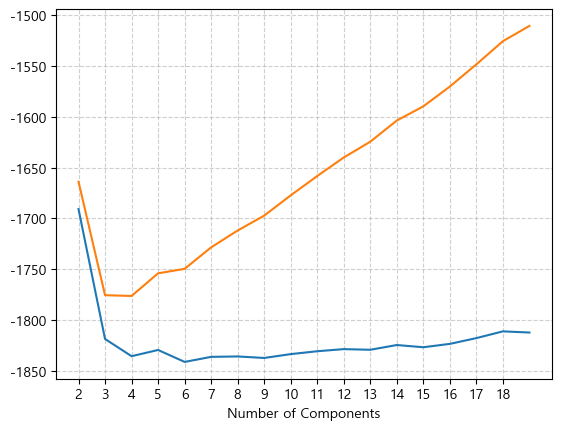

In [32]:
from sklearn.mixture import GaussianMixture

X = trimmed_growth.reshape(-1,1)

res = []
for k in range(2,20):
    gmm = GaussianMixture(n_components=k, random_state=0)
    gmm.fit(X)
    res.append((k, gmm.aic(X), gmm.bic(X)))


res_df = pd.DataFrame(res, columns=['n_components', 'AIC', 'BIC'])
import matplotlib.pyplot as plt
Ks = np.arange(1, len(res_df) + 1)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.xticks(np.arange(1, max(Ks) + 1, 1))
plt.plot(res_df['n_components'], res_df['AIC'], label='AIC')
plt.plot(res_df['n_components'], res_df['BIC'], label='BIC')
plt.xlabel('Number of Components')
print(res)


# 분포가정 검정

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# -----------------------------
# 1) 분포 적합 (Normal vs Student-t)
# -----------------------------
def fit_normal(x: np.ndarray):
    """정규분포 MLE: mu, sigma"""
    x = np.asarray(x, dtype=float)
    mu, sigma = stats.norm.fit(x)  # MLE
    return {"dist": "normal", "mu": mu, "sigma": sigma}

def fit_student_t(x: np.ndarray):
    """Student-t MLE: df, loc, scale"""
    x = np.asarray(x, dtype=float)
    df, loc, scale = stats.t.fit(x)  # MLE
    return {"dist": "student_t", "df": df, "loc": loc, "scale": scale}

def loglik_normal(x, params):
    mu, sigma = params["mu"], params["sigma"]
    return np.sum(stats.norm.logpdf(x, loc=mu, scale=sigma))

def loglik_student_t(x, params):
    df, loc, scale = params["df"], params["loc"], params["scale"]
    return np.sum(stats.t.logpdf(x, df=df, loc=loc, scale=scale))

def aic_bic(loglik: float, k_params: int, n: int):
    """AIC = 2k - 2LL, BIC = k ln(n) - 2LL"""
    aic = 2 * k_params - 2 * loglik
    bic = k_params * np.log(n) - 2 * loglik
    return aic, bic


# -----------------------------
# 2) 꼬리/분위수 기반 메트릭
# -----------------------------
def model_ppf(q, model_params):
    if model_params["dist"] == "normal":
        return stats.norm.ppf(q, loc=model_params["mu"], scale=model_params["sigma"])
    elif model_params["dist"] == "student_t":
        return stats.t.ppf(q, df=model_params["df"], loc=model_params["loc"], scale=model_params["scale"])
    else:
        raise ValueError("Unknown distribution")

def model_cdf(x, model_params):
    if model_params["dist"] == "normal":
        return stats.norm.cdf(x, loc=model_params["mu"], scale=model_params["sigma"])
    elif model_params["dist"] == "student_t":
        return stats.t.cdf(x, df=model_params["df"], loc=model_params["loc"], scale=model_params["scale"])
    else:
        raise ValueError("Unknown distribution")

def quantile_distance(x, model_params, Q=(0.01, 0.05, 0.10), agg="l1"):
    """
    경험분포 분위수 vs 모델 분위수 거리
    agg: 'l1' (절대오차합), 'l2' (제곱오차합)
    """
    x = np.asarray(x, dtype=float)
    emp = np.quantile(x, Q)
    theo = np.array([model_ppf(q, model_params) for q in Q])
    diff = emp - theo
    if agg == "l1":
        return float(np.sum(np.abs(diff)))
    elif agg == "l2":
        return float(np.sum(diff**2))
    else:
        raise ValueError("agg must be 'l1' or 'l2'")

def tail_exceedance_error(x, model_params, thresholds):
    """
    임계값 tau들에 대해 P(X < tau) 오차
    반환: 각 tau별 오차 dict + 평균오차
    """
    x = np.asarray(x, dtype=float)
    out = {}
    for tau in thresholds:
        p_emp = np.mean(x < tau)
        p_mod = float(model_cdf(tau, model_params))
        out[tau] = abs(p_emp - p_mod)
    out["mean_abs_error"] = float(np.mean(list(out.values())))
    return out


# -----------------------------
# 3) 첨도(peak/tail) 관련: kurtosis gap
# -----------------------------
def sample_excess_kurtosis(x):
    # Fisher's definition: 정규분포 excess kurtosis = 0
    x = np.asarray(x, dtype=float)
    return float(stats.kurtosis(x, fisher=True, bias=False))

def theoretical_excess_kurtosis(model_params):
    """
    정규분포: excess = 0
    Student-t: excess = 6/(df-4) (df>4), df<=4면 무한대(정의 불가)
    """
    if model_params["dist"] == "normal":
        return 0.0
    elif model_params["dist"] == "student_t":
        df = float(model_params["df"])
        if df <= 4:
            return np.inf
        return 6.0 / (df - 4.0)
    else:
        raise ValueError("Unknown distribution")

def kurtosis_gap(x, model_params):
    emp_ex = sample_excess_kurtosis(x)
    theo_ex = theoretical_excess_kurtosis(model_params)
    if np.isinf(theo_ex):
        return {"emp_excess_kurtosis": emp_ex, "theo_excess_kurtosis": theo_ex, "gap": np.inf}
    return {"emp_excess_kurtosis": emp_ex, "theo_excess_kurtosis": theo_ex, "gap": float(abs(emp_ex - theo_ex))}


# -----------------------------
# 4) 정책 민감 구간: downside semivariance / ES
# -----------------------------
def downside_semivariance(x, center="mean"):
    """
    SV = E[(X - c)^2 | X < c]
    center: 'mean' 또는 특정 숫자
    """
    x = np.asarray(x, dtype=float)
    c = float(np.mean(x)) if center == "mean" else float(center)
    below = x[x < c]
    if below.size == 0:
        return np.nan
    return float(np.mean((below - c) ** 2))

def empirical_var_es(x, alpha=0.05):
    """
    경험적 VaR_alpha (하위 alpha 분위수), ES_alpha (그 이하 평균)
    """
    x = np.asarray(x, dtype=float)
    var = float(np.quantile(x, alpha))
    tail = x[x <= var]
    es = float(np.mean(tail)) if tail.size > 0 else np.nan
    return var, es

def model_var_es(model_params, alpha=0.05, n_mc=200000, seed=0):
    """
    모델 기반 VaR/ES:
    - VaR은 ppf로 정확히 계산
    - ES는 closed-form이 분포별로 다르므로 (간단히) MC로 근사
      (n_mc 충분히 크게 하면 안정적)
    """
    var = float(model_ppf(alpha, model_params))
    rng = np.random.default_rng(seed)

    if model_params["dist"] == "normal":
        samp = rng.normal(loc=model_params["mu"], scale=model_params["sigma"], size=n_mc)
    elif model_params["dist"] == "student_t":
        samp = stats.t.rvs(df=model_params["df"], loc=model_params["loc"], scale=model_params["scale"],
                           size=n_mc, random_state=rng)
    else:
        raise ValueError("Unknown distribution")

    tail = samp[samp <= var]
    es = float(np.mean(tail)) if tail.size > 0 else np.nan
    return var, es

def es_error(x, model_params, alphas=(0.05, 0.10), n_mc=200000, seed=0):
    """
    ES 적합도: |ES_emp - ES_model| 및 |VaR_emp - VaR_model|
    """
    x = np.asarray(x, dtype=float)
    out = {}
    for a in alphas:
        var_emp, es_emp = empirical_var_es(x, alpha=a)
        var_mod, es_mod = model_var_es(model_params, alpha=a, n_mc=n_mc, seed=seed)
        out[a] = {
            "VaR_emp": var_emp, "VaR_model": var_mod, "VaR_abs_err": abs(var_emp - var_mod),
            "ES_emp": es_emp, "ES_model": es_mod, "ES_abs_err": abs(es_emp - es_mod)
        }
    return out


# -----------------------------
# 5) 한 번에 요약 리포트 만들기
# -----------------------------
def evaluate_fit_metrics(x, Q=(0.01, 0.05, 0.10), tail_thresholds=None, es_alphas=(0.05, 0.10),
                         n_mc_es=200000, seed=0):
    """
    x: 1D array (성장률)
    tail_thresholds: None이면 하위 분위수 기반으로 자동 생성 (예: 1%, 5%, 10% 분위수)
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 10:
        raise ValueError("표본이 너무 적어요. (n < 10)")

    # fit
    pN = fit_normal(x)
    pT = fit_student_t(x)

    # loglik
    llN = loglik_normal(x, pN)
    llT = loglik_student_t(x, pT)

    # AIC/BIC (Normal: 2 params, t: 3 params)
    aicN, bicN = aic_bic(llN, k_params=2, n=n)
    aicT, bicT = aic_bic(llT, k_params=3, n=n)

    # tail thresholds 자동 생성(정책 임계값이 따로 없으면 분위수 사용)
    if tail_thresholds is None:
        tail_thresholds = [float(np.quantile(x, q)) for q in Q]

    # metrics
    rows = []
    for name, params, ll, aic, bic in [
        ("Normal", pN, llN, aicN, bicN),
        ("Student-t", pT, llT, aicT, bicT),
    ]:
        qdist = quantile_distance(x, params, Q=Q, agg="l1")
        tail_err = tail_exceedance_error(x, params, thresholds=tail_thresholds)
        k_gap = kurtosis_gap(x, params)
        sv = downside_semivariance(x, center="mean")
        es_err = es_error(x, params, alphas=es_alphas, n_mc=n_mc_es, seed=seed)

        rows.append({
            "Model": name,
            "LogLik": ll,
            "AIC": aic,
            "BIC": bic,
            "QuantileDist_L1(Q)": qdist,
            "TailExceed_MAE": tail_err["mean_abs_error"],
            "ExcessKurtosis_emp": k_gap["emp_excess_kurtosis"],
            "ExcessKurtosis_theo": k_gap["theo_excess_kurtosis"],
            "ExcessKurtosis_gap": k_gap["gap"],
            "DownsideSemiVar_emp": sv,
            "ES_details": es_err,            # dict로 남김(아래에서 별도 표로 풀어도 됨)
            "TailExceed_details": tail_err,  # dict로 남김
        })

    summary_df = pd.DataFrame(rows).sort_values(by="AIC")
    return summary_df, pN, pT




In [35]:

# -----------------------------
# 6) 사용 예시
# -----------------------------
all_growth_clean = X  # 이상치 제거 후 1D array
summary_df, pN, pT = evaluate_fit_metrics(
    all_growth_clean,
    Q=(0.01, 0.05, 0.10),
    tail_thresholds=None,      # None이면 자동 생성
    es_alphas=(0.05, 0.10),
    n_mc_es=200000,            # ES는 MC근사라 표본 크게 잡을수록 안정
    seed=0
)
print(summary_df[["Model","LogLik","AIC","BIC","QuantileDist_L1(Q)","TailExceed_MAE","ExcessKurtosis_gap","DownsideSemiVar_emp"]])
print("Normal params:", pN)
print("Student-t params:", pT)

# ES 오차(자세히 보고 싶으면)
for m in summary_df["Model"]:
    es_info = summary_df.loc[summary_df["Model"]==m, "ES_details"].values[0]
    print(m, es_info)

       Model      LogLik          AIC          BIC  QuantileDist_L1(Q)  \
1  Student-t  857.109556 -1708.219111 -1692.048567            0.049787   
0     Normal  828.940773 -1653.881545 -1643.101182            0.044868   

   TailExceed_MAE  ExcessKurtosis_gap  DownsideSemiVar_emp  
1        0.003301           19.472689             0.017429  
0        0.008514            0.657715             0.017429  
Normal params: {'dist': 'normal', 'mu': 0.07942570229894742, 'sigma': 0.14505673051963672}
Student-t params: {'dist': 'student_t', 'df': 4.29805661590078, 'loc': 0.0727976558885765, 'scale': 0.11169847025457824}
Student-t {0.05: {'VaR_emp': -0.16121642195423033, 'VaR_model': -0.16066010501601022, 'VaR_abs_err': 0.0005563169382201139, 'ES_emp': -0.23114701284857755, 'ES_model': -0.27371972447252607, 'ES_abs_err': 0.04257271162394852}, 0.1: {'VaR_emp': -0.09136128101767688, 'VaR_model': -0.09619013836814988, 'VaR_abs_err': 0.004828857350473004, 'ES_emp': -0.1766090191286442, 'ES_model': -0

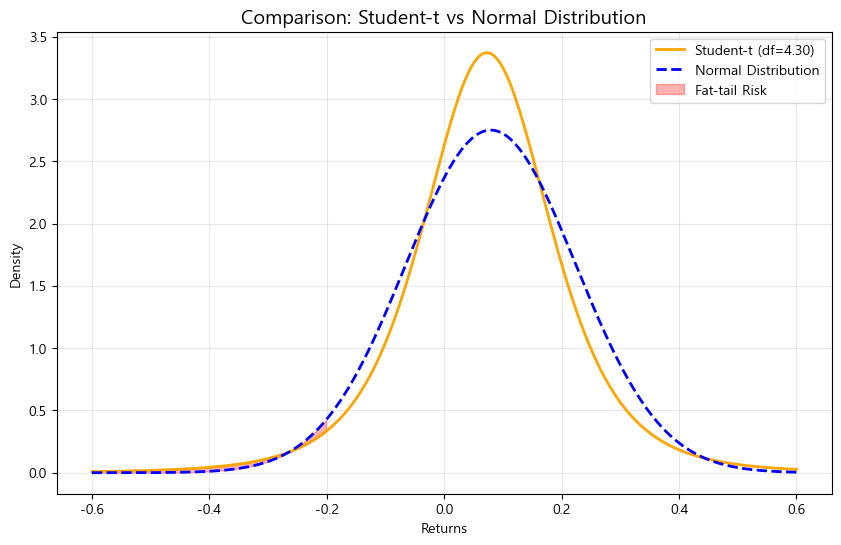

In [36]:
 import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. 파라미터 설정
t_df, t_loc, t_scale = 4.29805661590078, 0.0727976558885765, 0.11169847025457824
# 정규분포는 비교를 위해 t-분포와 동일한 평균(loc)과 표준편차를 사용하거나, 
# 이전에 제공된 정규분포 파라미터(mu=0.079, sigma=0.145)를 사용할 수 있습니다.
n_mu, n_sigma = 0.07942570229894742, 0.14505673051963672

# 2. X축 범위 설정 (수익률 범위)
x = np.linspace(-0.6, 0.6, 1000)

# 3. 확률밀도함수(PDF) 계산
t_pdf = stats.t.pdf(x, df=t_df, loc=t_loc, scale=t_scale)
n_pdf = stats.norm.pdf(x, loc=n_mu, scale=n_sigma)

# 4. 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(x, t_pdf, label=f'Student-t (df={t_df:.2f})', color='orange', lw=2)
plt.plot(x, n_pdf, label='Normal Distribution', color='blue', linestyle='--', lw=2)

# 꼬리 부분을 강조하기 위한 영역 표시 (예: 하락장 위험)
plt.fill_between(x, t_pdf, n_pdf, where=(x < -0.2), color='red', alpha=0.3, label='Fat-tail Risk')

plt.title('Comparison: Student-t vs Normal Distribution', fontsize=14)
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [80]:
country_means = growth.drop(columns=[2020]).mean(axis=1)
country_means.mean(), country_means.std(ddof=1)

(0.10792075367109275, 0.08199010593961072)

In [87]:
all_growth_wo_2020 = (
    # 격리
    growth.drop(columns=[2020, 2021, 2022, 2023])
    .values.flatten()
)
all_growth_wo_2020 = all_growth_wo_2020[~np.isnan(all_growth_wo_2020)]

print(f'''전체 연도별 로그 성장률 (2020년 제외)의 평균: {all_growth_wo_2020.mean():.5f}
전체 연도별 로그 성장률 (2020년 제외)의 분산: {all_growth_wo_2020.var(ddof=1):.5f}
전체 연도별 로그 성장률 (2020년 제외)의 표준편차: {all_growth_wo_2020.std(ddof=1):.5f}''')


전체 연도별 로그 성장률 (2020년 제외)의 평균: 0.03812
전체 연도별 로그 성장률 (2020년 제외)의 분산: 0.07066
전체 연도별 로그 성장률 (2020년 제외)의 표준편차: 0.26582


mean 0.015983465076052226 std 0.45988452886725434
skew -1.9976692684603798 kurtosis(excess) 38.128679047017414


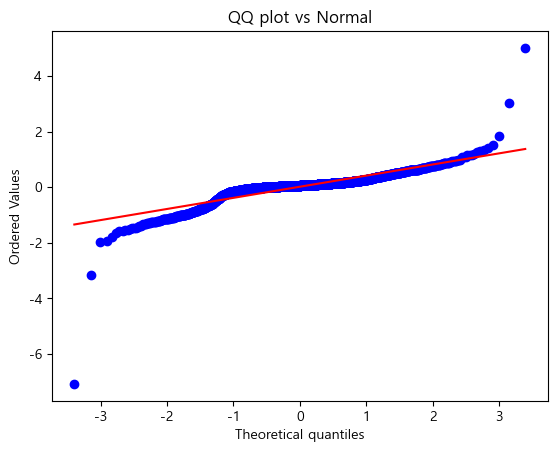

In [57]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = growth.values.flatten()
x = x[~np.isnan(x)]

print("mean", x.mean(), "std", x.std(ddof=1))
print("skew", stats.skew(x), "kurtosis(excess)", stats.kurtosis(x))  # excess=0이면 정규

# QQ plot (정규 기준)
stats.probplot(x, dist="norm", plot=plt)
plt.title("QQ plot vs Normal")
plt.show()


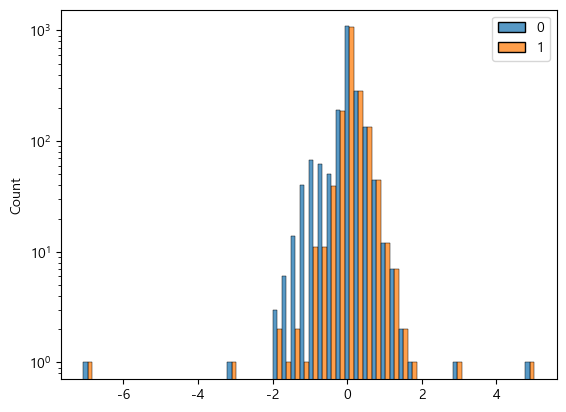

In [78]:
sns.histplot([x,all_growth_wo_2020], bins=50, multiple='dodge')
plt.yscale('log')

In [94]:
x = growth.values.flatten()
summary = pd.DataFrame([{
    'Min': np.min(x),
    'Q1': np.percentile(x, 25),
    'Mean': np.mean(x),
    'Median': np.median(x),
    'Q3': np.percentile(x, 75),
    'Max': np.max(x),
    'Std': np.std(x, ddof=1)
}])
(summary*100).round(3)


,Min,Q1,Mean,Median,Q3,Max,Std
0,-708.132,-3.399,1.598,5.993,17.081,501.254,45.988


* 연구결과 첫번쨰 figure에 작성함  
* 성장률 데이터입니다.  
Min	Q1	Mean	Median	Q3	Max	Std  
0	-7.081323	-0.033992	0.015983	0.059929	0.170811	5.012535	0.459885  

In [105]:
x2019 = pd.to_numeric(df[2019], errors="coerce").dropna()

cap_2019_stats = pd.DataFrame([{
    "Baseline Year": 2019,
    "N": len(x2019),
    "Min": x2019.min(),
    "Q1": x2019.quantile(0.25),
    "Mean": x2019.mean(),
    "Median": x2019.median(),
    "Q3": x2019.quantile(0.75),
    "Max": x2019.max(),
    "Std. Dev.": x2019.std(ddof=1),
}])

cap_2019_stats.round(0)

,Baseline Year,N,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
0,2019,183,3271.0,110435.0,3198154.0,409384.0,2158524.0,81575829.0,8362697.0


<Axes: xlabel='2019', ylabel='Count'>

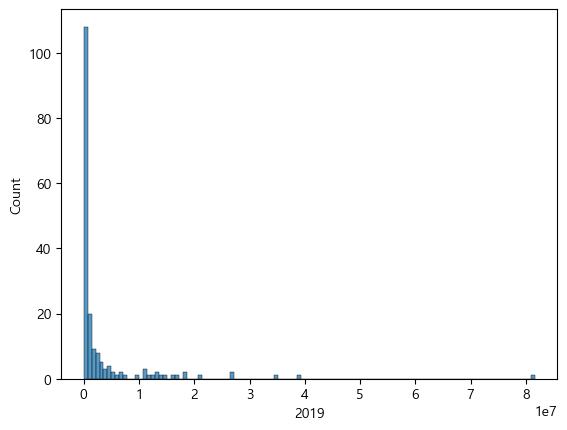

In [104]:
sns.histplot(df[2019])
# plt.xscale('log')

In [70]:
e_cap = df[2019].sum()
df.columns
for i in df.columns:
    print(f'{i}년: {df[i].sum() - e_cap}')

2013년: -147297594.70523357
2014년: -124524479.10950053
2015년: -98200548.03145301
2016년: -73764711.60764265
2017년: -45924168.50533974
2018년: -18705410.644227862
2019년: 0.0
2020년: -332711108.31636906
2021년: -312197328.7960069
2022년: -187219813.15386552
2023년: -93223182.03733599
2024년: -39227673.819178104


In [71]:
e_cap = df[2019]
df.columns
for i in df.columns:
    emission_offset = (df[i] - e_cap).clip(lower=0)
    print(f'{i}년: {emission_offset.sum()}')

2013년: 7956378.718986341
2014년: 8893371.302678265
2015년: 9334127.933080701
2016년: 11207080.606447073
2017년: 12913800.70333068
2018년: 15739436.766790904
2019년: 0.0
2020년: 36788.9955828251
2021년: 181454.04160164177
2022년: 1500065.6503684893
2023년: 6802136.674289644
2024년: 16375124.588879216


# 시뮬레이션

In [72]:
# 성장률 통계
# u, s
# g_mean, g_std = summary['Mean'], summary['Std']
g_mean, g_std = u, s   # 밑에서 구한 글로벌 성장률 및 표준편차, 코로나 이전
g_mean, g_std

(0.04832031672322342, 0.00814891000621717)

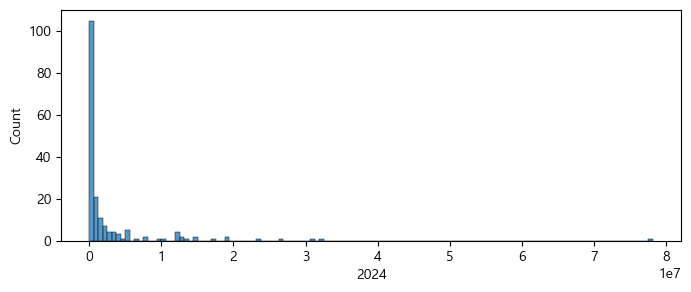

(<Figure size 800x300 with 1 Axes>,
 <Axes: xlabel='2024', ylabel='Count'>,
 None)

In [73]:
# 배출량 초기값, E_0 시점
e_0 = df[2024]
plt.figure(figsize=(8,3)), sns.histplot(e_0), plt.show()

In [74]:
# 시나리오 설정
random_seed = 42
np.random.seed(random_seed)
n = 10_000
start_year = 2024
end_year = 2050
years = end_year - start_year
n_country = len(df.index)

In [75]:
g_sim = np.random.normal(
    loc=g_mean,
    scale=g_std,
    size=(n, n_country, years)
)
g_sim.shape

(10000, 183, 26)

In [76]:
g_sim[:, :, 0]

array([[0.052368  , 0.03894097, 0.04280414, ..., 0.04643547, 0.0597853 ,
        0.03979557],
       [0.04289785, 0.07077234, 0.05448487, ..., 0.05505815, 0.05269471,
        0.05002628],
       [0.06337842, 0.05470218, 0.06589222, ..., 0.0494429 , 0.05584203,
        0.05229139],
       ...,
       [0.04259166, 0.0571981 , 0.05945065, ..., 0.06538394, 0.06162083,
        0.05236992],
       [0.05495892, 0.03585246, 0.05229726, ..., 0.03915247, 0.04598432,
        0.05163776],
       [0.05145487, 0.05323874, 0.04480926, ..., 0.04185974, 0.04054112,
        0.0644367 ]])

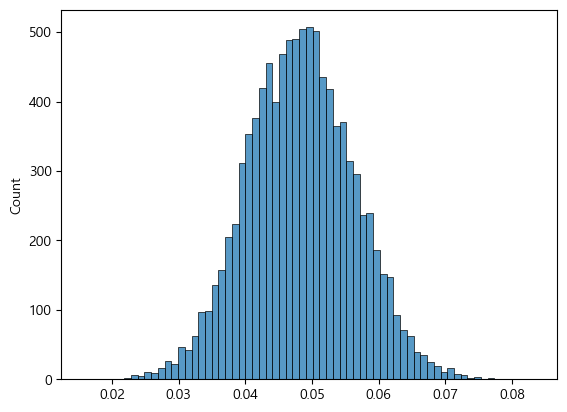

(<Axes: ylabel='Count'>, None)

In [77]:
sample = np.random.choice(g_sim.flatten(), size=10_000, replace=False)
sns.histplot(sample), plt.show()

In [78]:
# 누적 성장률
cumulative_growth = np.cumsum(g_sim, axis=2)
cumulative_growth.shape

(10000, 183, 26)

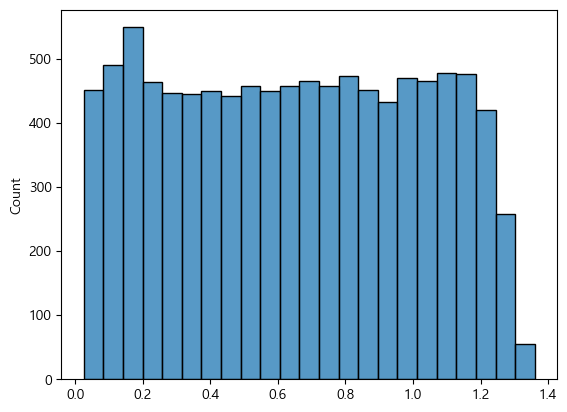

In [79]:
sample = np.random.choice(cumulative_growth.flatten(), size=10_000, replace=False)
sns.histplot(sample)
plt.show()

In [80]:
# 배출량
emissions = e_0.values[np.newaxis, :, np.newaxis] * np.exp(cumulative_growth)
emissions.shape

(10000, 183, 26)

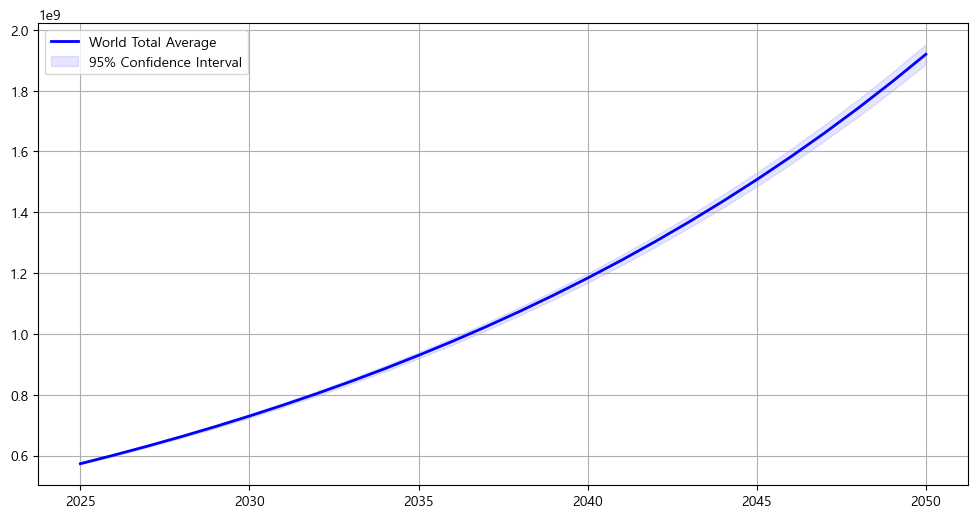

In [81]:
# 1. 모든 시나리오(s)와 국가(i)에 대해 연도별(t)로 합산 후 평균
# emissions shape: (10000, 193, 50)
# world_total_per_scenario: (10000, 50) -> 각 시나리오별 지구 전체 배출량
world_total_per_scenario = np.sum(emissions, axis=1)

# world_average_path: (50,) -> 10,000개 시나리오의 평균적인 지구 배출량 경로
world_average_path = np.mean(world_total_per_scenario, axis=0)

# world_average_path의 실제 길이에 맞춰 years_range를 생성합니다.
actual_years_count = world_average_path.shape[0]

# 초기 연도가 2025년이라면:
years_range = np.arange(2025, 2025 + actual_years_count)

# 이제 다시 그려보세요!
plt.figure(figsize=(12, 6))
plt.plot(years_range, world_average_path, color='blue', lw=2, label='World Total Average')

# 신뢰구간도 동일한 길이를 사용하게 됩니다.
upper_bound = np.percentile(world_total_per_scenario, 97.5, axis=0)
lower_bound = np.percentile(world_total_per_scenario, 2.5, axis=0)
plt.grid(True)
plt.fill_between(years_range, lower_bound, upper_bound, color='blue', alpha=0.1, label='95% Confidence Interval')
plt.legend()
plt.show()

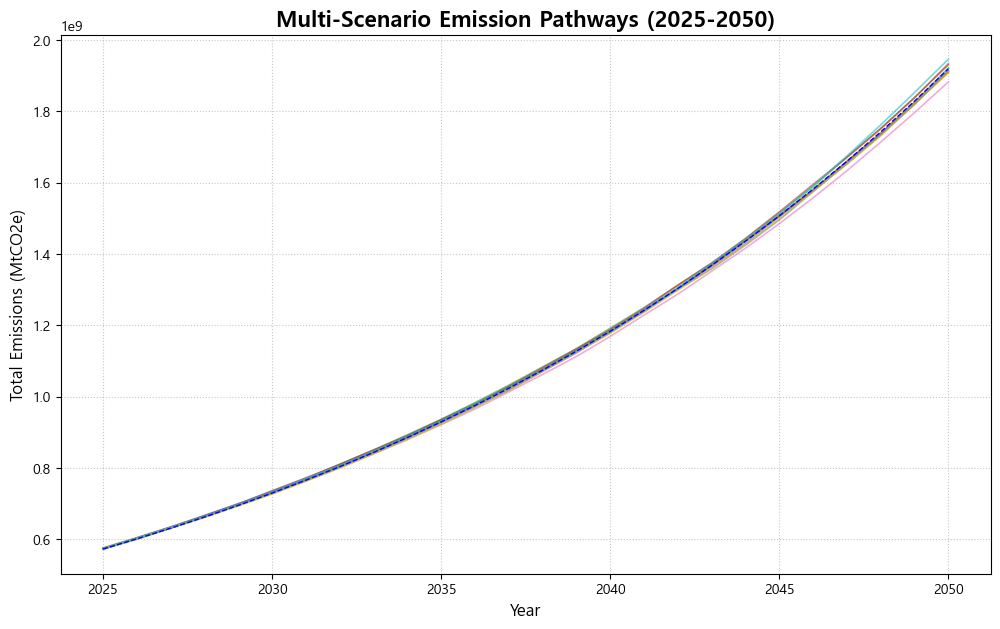

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 실제 데이터 길이에 맞게 연도 설정
actual_years_count = world_average_path.shape[0]
years_range = np.arange(2025, 2025 + actual_years_count)

plt.figure(figsize=(12, 7))

# 2. 개별 시나리오 n개 (다양한 색상으로 역동성 부여)
# 컬러맵을 사용하여 n개의 서로 다른 색상을 생성합니다.
n = 10
colors = plt.cm.tab10(np.linspace(0, 1, n)) 

for i in range(n):
    plt.plot(years_range, world_total_per_scenario[i, :actual_years_count], 
             lw=1.2, alpha=0.6, color=colors[i], 
             label=f'Scenario {i+1}')

# 3. 신뢰구간 (부드러운 연두색 계열로 배경 처리)
upper_bound = np.percentile(world_total_per_scenario, 97.5, axis=0)
lower_bound = np.percentile(world_total_per_scenario, 2.5, axis=0)

# plt.fill_between(years_range, lower_bound[:actual_years_count], upper_bound[:actual_years_count], 
#                  color='limegreen', alpha=0.15, label='95% Confidence Interval')

# 4. 전체 평균선 (가장 눈에 띄는 굵은 검정색 점선)
plt.plot(years_range, world_average_path, color='blue', lw=1, ls='--', label='World Average Trend')

# 그래프 꾸미기
plt.title('Multi-Scenario Emission Pathways (2025-2050)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Emissions (MtCO2e)', fontsize=12)

# 범례를 그래프 밖으로 빼서 시나리오 라벨이 겹치지 않게 합니다.
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

# plt.tight_layout() # 범례가 잘리지 않도록 조정
plt.show()

In [83]:
# 1. 국가별 로그 성장률의 평균(mu)과 표준편차(sigma) 계산
# df_log_growth가 [국가 x 연도] 형태라고 가정할 때 (axis=1은 연도 방향 계산)
country_means = df.mean(axis=1)
country_stds = df.std(axis=1)

# 2. 결과 확인 (Series 형태)
# 인덱스는 국가명, 값은 각 국가의 mu와 sigma
print(country_means.head(), country_means.shape)
print(country_stds.head(), country_stds.shape)

Reference area
Australia    1.139975e+07
Austria      2.167420e+06
Belgium      3.503589e+06
Canada       1.048438e+07
Chile        1.825489e+06
dtype: float64 (183,)
Reference area
Australia    3.641109e+06
Austria      5.505376e+05
Belgium      5.004607e+05
Canada       2.749509e+06
Chile        3.538089e+05
dtype: float64 (183,)


In [84]:
# g_sim 형태: (10000, 193, 26)
n_sim = 10000
n_countries = 183
years = 26

# 빈 배열 생성
g_sim = np.zeros((n_sim, n_countries, years))

for i in range(n_countries):
    # i번째 국가의 평균과 표준편차를 사용하여 10,000회 시나리오 생성
    # 각 국가별로 (10000, 26) 크기의 난수 행렬이 들어감
    g_sim[:, i, :] = np.random.normal(
        loc=country_means.iloc[i], 
        scale=country_stds.iloc[i], 
        size=(n_sim, years)
    )

In [85]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# 1. 설정
k_values = [1, 2, 3, 5, 10, 20, 30, 50, 100, 183] # 주요 k값들
n_sim = 10000
years_count = emissions.shape[2] # 26년

# 결과를 저장할 그릇 (연도별, k별 리스크 총합)
# 리스크 = 각 그룹의 시나리오 간 표준편차의 합
risk_results = np.zeros((years_count, len(k_values)))

for t in tqdm(range(years_count)):
    year_data = emissions[:, :, t] # (10000, 183)
    
    for k_idx, k in enumerate(k_values):
        num_groups = int(np.ceil(183 / k))
        # 각 시나리오별 그룹 합계를 담을 행렬
        all_scenario_groups = np.zeros((n_sim, num_groups))
        
        for s in range(n_sim):
            # 매 시나리오마다 국가 순서 셔플 (중요!)
            indices = np.random.permutation(183)
            shuffled_data = year_data[s, indices]
            
            # k개씩 묶어서 그룹 합계 계산
            for g_idx, start_idx in enumerate(range(0, 183, k)):
                group_sum = np.sum(shuffled_data[start_idx : start_idx + k])
                all_scenario_groups[s, g_idx] = group_sum
        
        # 각 그룹 슬롯별로 10,000개 시나리오 사이의 표준편차 계산
        group_vols = np.std(all_scenario_groups, axis=0)
        
        # 해당 연도, 해당 k에서의 전체 변동성 총합
        risk_results[t, k_idx] = np.sum(group_vols)

print("분석 완료!")

100%|██████████| 26/26 [08:52<00:00, 20.46s/it]

분석 완료!


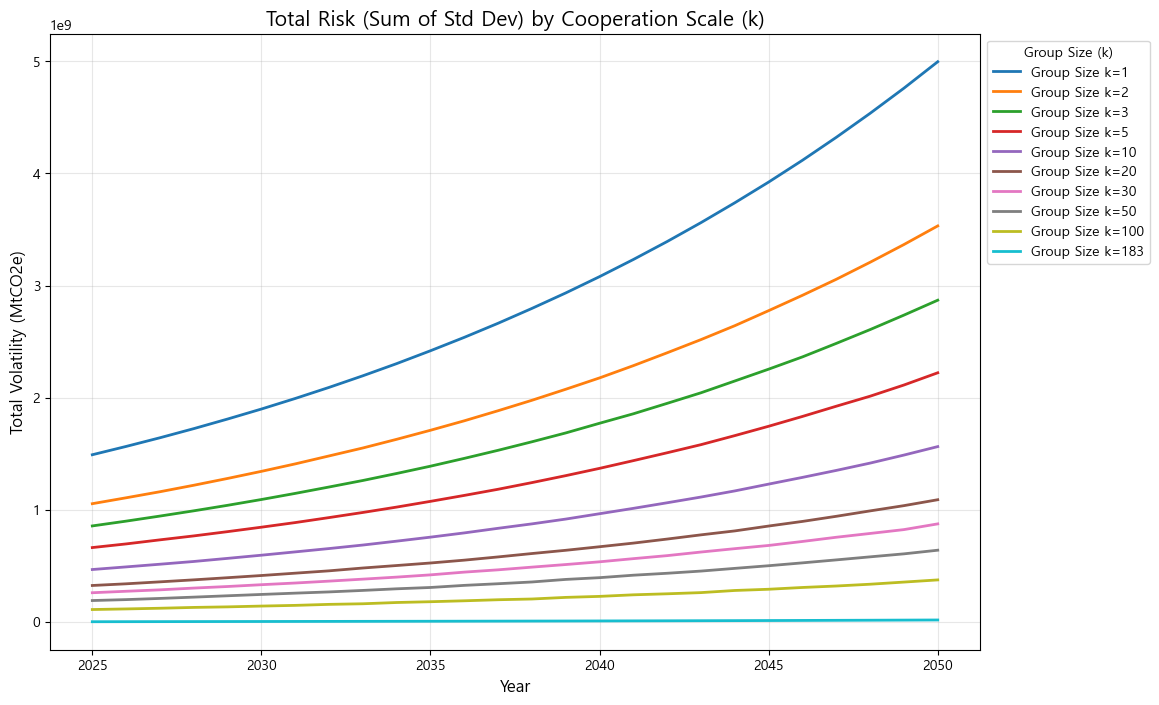

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
years_plot = np.arange(2025, 2025 + years_count)

for i, k in enumerate(k_values):
    # k가 1일 때(가장 높음)부터 183일 때(가장 낮음)까지 선으로 표시
    plt.plot(years_plot, risk_results[:, i], label=f'Group Size k={k}', lw=2)

plt.title('Total Risk (Sum of Std Dev) by Cooperation Scale (k)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Volatility (MtCO2e)', fontsize=12)
plt.legend(title="Group Size (k)", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.show()

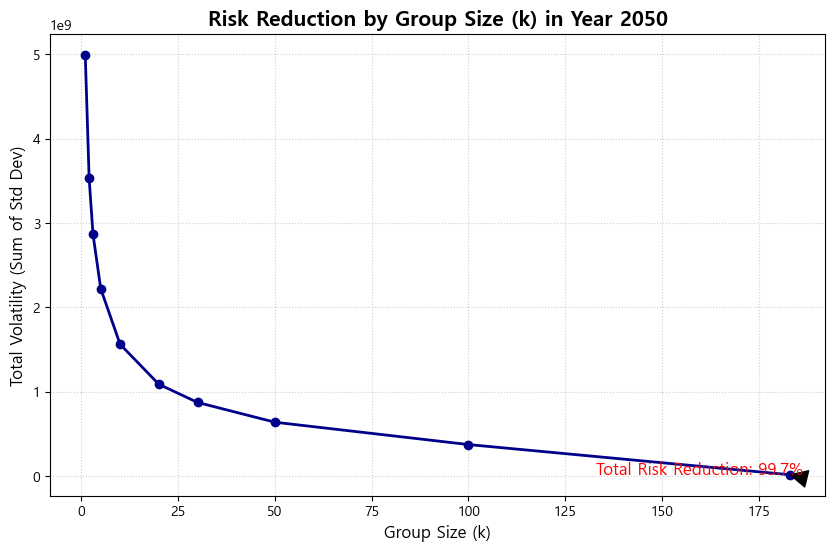

In [91]:
# 마지막 연도(2050년) 인덱스 (26년차 기준 25번 인덱스)
last_year_idx = years_count - 1
risk_at_2050 = risk_results[last_year_idx, :]

# 시각화
plt.figure(figsize=(10, 6))

# k값에 따른 리스크 변화 (막대 그래프 또는 선 그래프)
plt.plot(k_values, risk_at_2050, marker='o', linestyle='-', color='darkblue', lw=2)

# 그래프 장식
plt.title('Risk Reduction by Group Size (k) in Year 2050', fontsize=15, fontweight='bold')
plt.xlabel('Group Size (k)', fontsize=12)
plt.ylabel('Total Volatility (Sum of Std Dev)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# k=1일 때와 k=183일 때의 리스크 감소율 계산 및 표시
reduction_pct = (1 - risk_at_2050[-1] / risk_at_2050[0]) * 100
plt.annotate(f'Total Risk Reduction: {reduction_pct:.1f}%', 
             xy=(k_values[-1], risk_at_2050[-1]), 
             xytext=(k_values[-1]-50, risk_at_2050[-1]*1.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, color='red')

plt.show()

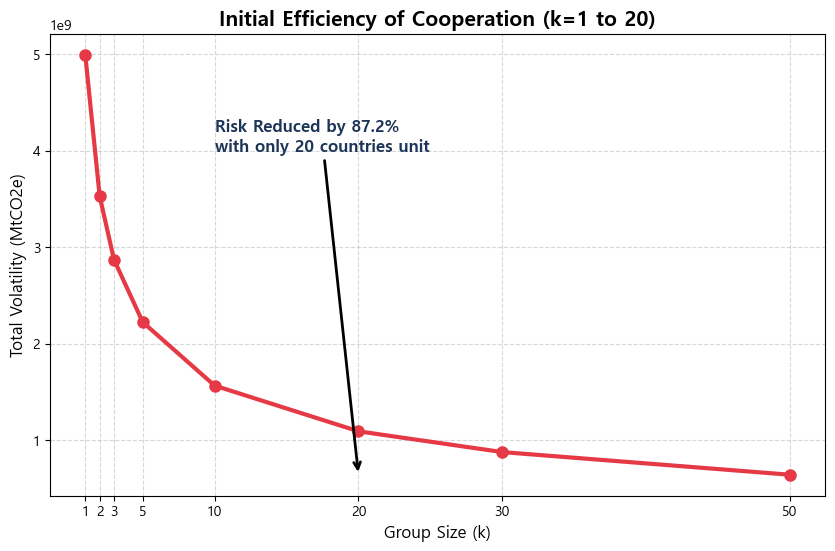

In [94]:
# 1. k_values 범위를 1부터 20까지 재설정 (전체 국가 루프를 돌렸다면 슬라이싱)
# 만약 앞에서 k_values를 [1, 2, 3, 5, 10, 20...]으로 하셨다면 해당 인덱스만 추출합니다.
target_k = [k for k in k_values if k <= 50]
target_risk_2050 = risk_at_2050[:len(target_k)]

plt.figure(figsize=(10, 6))

# k=1부터 20까지의 리스크 곡선
plt.plot(target_k, target_risk_2050, marker='o', markersize=8, 
         linestyle='-', color='#E63946', lw=3, label='Total Risk at 2050')

# 그래프 스타일링
plt.title('Initial Efficiency of Cooperation (k=1 to 20)', fontsize=15, fontweight='bold')
plt.xlabel('Group Size (k)', fontsize=12)
plt.ylabel('Total Volatility (MtCO2e)', fontsize=12)
plt.xticks(target_k) # 모든 k값을 X축에 표시
plt.grid(True, linestyle='--', alpha=0.5)

# k=1 대비 k=20의 감소폭 강조
reduction_k20 = (1 - target_risk_2050[-1] / target_risk_2050[0]) * 100
plt.annotate(f'Risk Reduced by {reduction_k20:.1f}%\nwith only 20 countries unit', 
             xy=(20, target_risk_2050[-1]), 
             xytext=(10, target_risk_2050[0] * 0.8),
             arrowprops=dict(arrowstyle='->', lw=2, color='black'),
             fontsize=12, fontweight='bold', color='#1D3557')

plt.show()

# 전 세계를 하나로 보고 성장률을 도출해보자.

In [60]:
global_sum = df.sum(axis=0)
global_g = np.log(global_sum).diff()
global_g.mean(), global_g.std(ddof=1)   

(0.020049467922341725, 0.30334299247352897)

In [68]:
global_g_before_corona = global_g.loc[2014:2019]
print(f'''
글로벌 연도별 로그 성장률 (2014-2019)의 평균: 코로나 이전
{global_g_before_corona.mean()}, {global_g_before_corona.std(ddof=1)}
''')


글로벌 연도별 로그 성장률 (2014-2019)의 평균: 코로나 이전
0.04832031672322342, 0.00814891000621717



In [69]:
u = global_g_before_corona.mean()
s = global_g_before_corona.std(ddof=1)

In [50]:
years = np.arange(2013, 2020).tolist()
df_num = df.copy()
df_num = np.log(df_num[years])  # 로그 변환

# 연도별 로그 성장률
growth = df_num.diff(axis=1).iloc[:, 1:]  # 2014~2024
display(growth)
print('''
연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.
''')

,2014,2015,2016,2017,2018,2019
Reference area,,,,,,
Australia,0.016912,0.032038,0.096944,0.068839,0.050418,-0.047948
Austria,0.051081,0.037339,0.030692,0.002293,0.108295,0.148626
Belgium,-0.016169,0.065790,0.015552,0.057642,0.070444,0.024954
Canada,0.060029,0.057680,0.080761,0.067795,0.051961,0.055086
Chile,0.020699,0.087653,0.056168,0.070641,0.051608,0.019733
...,...,...,...,...,...,...
Vanuatu,-0.095619,-0.091196,-0.102060,0.089843,0.148172,-0.095241
Venezuela,-0.325436,-0.170147,-0.052078,-0.276682,-0.081692,-0.245520
Viet Nam,0.073173,0.107736,0.162031,0.180549,0.156812,0.155372



연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.

